In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ejemplo árboles de decisión: Titanic

In [2]:
# Leemos los datos de Titanic
titanic_data = pd.read_csv("../data/otros/titanic.csv")
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Hagamos las dos tablas necesarias para el árbol "mujeres y niños primero"

# Primero necesitamos crear la variable de "mayor a 10 años" - hay que respetar los NaNs

titanic_data['mayor_10_anios'] = titanic_data.apply(lambda row: 1 if pd.notnull(row['Age']) and row['Age'] > 10 else 0, axis=1)

sobrev_sexo = titanic_data.groupby('Sex')['Survived'].mean()
sobrev_sexo_edad = titanic_data.groupby(['Sex','mayor_10_anios'])['Survived'].mean()

print(sobrev_sexo)
print("")
print(sobrev_sexo_edad)

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Sex     mayor_10_anios
female  0                 0.654762
        1                 0.773913
male    0                 0.222930
        1                 0.176190
Name: Survived, dtype: float64


In [4]:
# Aquí tu código para buscar un mejor corte para la edad, 
# u otra variable que encuentra una diferencia mayor en proporción de sobrevivientes.






## Construyamos un árbol de decisión sencillo

El siguiente código es un poco complejo, en las siguientes clases se verá con más detalle el código necesario para crear modelos.

In [5]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Crear conjunto de datos
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
pred = "Survived"

# Separar covariables y variable a predecir
X = titanic_data[features]
y = titanic_data[pred]

# Imputaremos media para numéricas y moda para categóricas - 
numerical_features = ["Age", "SibSp", "Parch", "Fare"]
categorical_features = ["Pclass", "Sex", "Embarked"]

X_num = X[numerical_features]
X_cat = X[categorical_features]

imputer_num = SimpleImputer(strategy='mean')
X_num_imputed = imputer_num.fit_transform(X_num)

imputer_cat = SimpleImputer(strategy='most_frequent')
X_cat_imputed = imputer_cat.fit_transform(X_cat)

# Transformaremos categóricas a dummies
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_cat_encoded = encoder.fit_transform(X_cat_imputed)
X_cat_encoded_df = pd.DataFrame(X_cat_encoded, columns=encoder.get_feature_names_out(categorical_features))

# Volvemos a juntar todo en un dataframe
X_processed = pd.concat([pd.DataFrame(X_num_imputed, columns=numerical_features), X_cat_encoded_df], axis=1)

# Modelo Árbol de Decisión
arbol_clasificacion = DecisionTreeClassifier(max_depth = 3)
arbol_clasificacion.fit(X_processed, y)
predicciones_arbol = arbol_clasificacion.predict(X_processed)


/Users/mariafernanda/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_encoders.py:828: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


¡Importante! En este proceso no separamos los datos en train y test. Aprenderemos a hacer esto en la siguiente clase, es un paso _vital_ en el pipeline de un modelo, pero por el momento solo queremos visualizar.

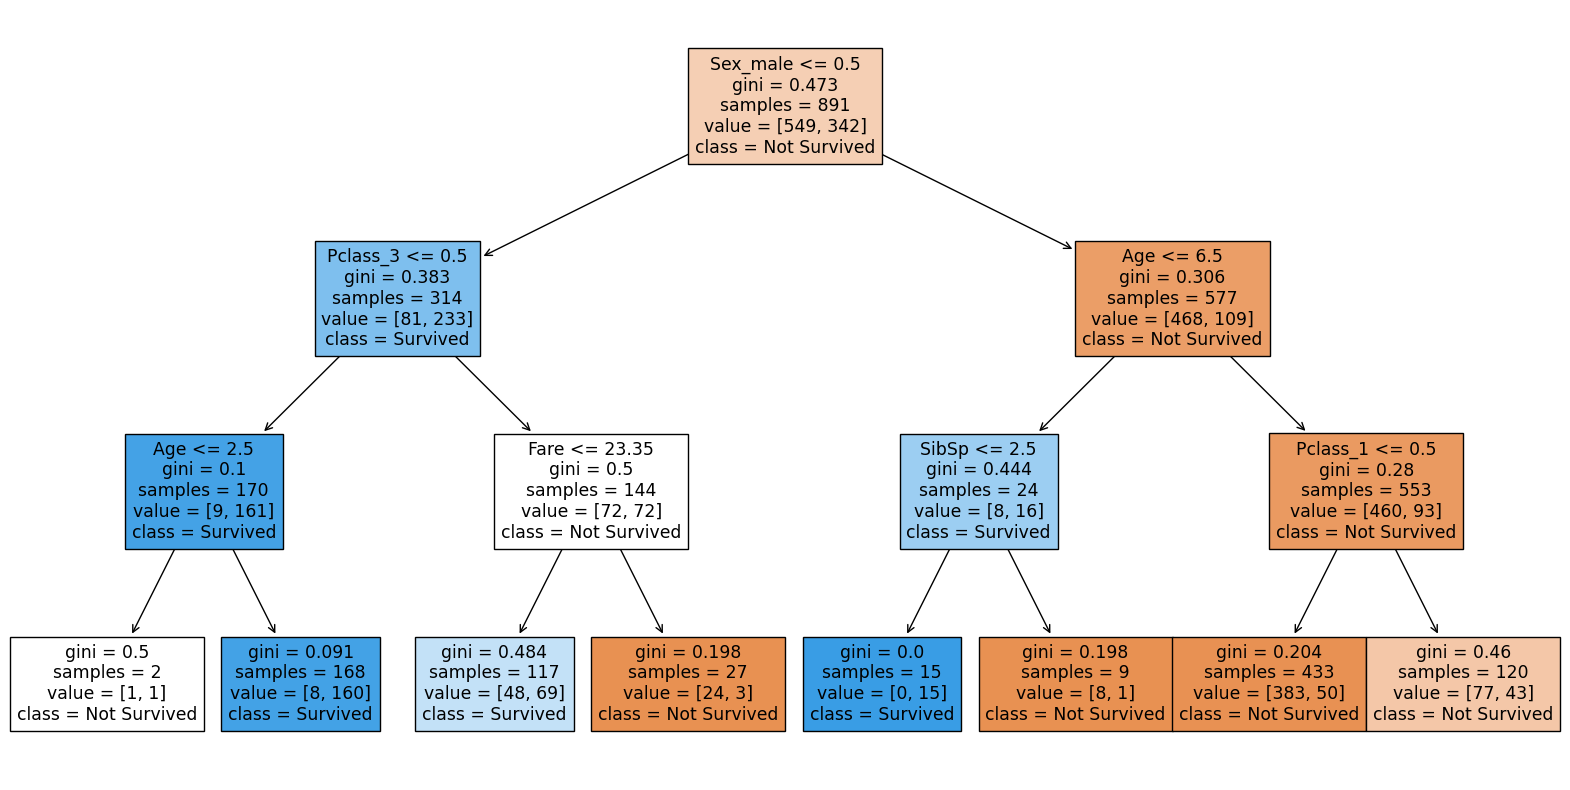

In [6]:
from sklearn.tree import plot_tree

# Visualize the decision tree
plt.figure(figsize=(20, 10))
plot_tree(arbol_clasificacion, feature_names=X_processed.columns, class_names=['Not Survived', 'Survived'], filled=True)
plt.show()

# Ejemplo KNN: iris

¿Recuerdan los datos _iris_ de la tarea de visualización? Vamos a usarlos otra vez.


In [7]:
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [8]:
# Crear conjunto de datos
features = ["sepal_length","sepal_width","petal_length","petal_width"]
pred = "species"

# Separar covariables y variable a predecir
X = iris[features]
y = iris[pred]

Vamos a crear 10 observaciones nuevas, con números aleatorios, para tratar de clasificarlas.

In [9]:
import random

random.seed(100)

min_values = X.min(axis=0)
max_values = X.max(axis=0)
obs_aleatorias = np.random.uniform(min_values, max_values, (10, 4))
obs_aleatorias_df = pd.DataFrame(obs_aleatorias, columns=iris.columns[0:4])
obs_aleatorias_df

,sepal_length,sepal_width,petal_length,petal_width
0,7.599253,3.832906,5.441349,2.393263
1,5.242506,2.306225,2.743974,0.863973
2,6.325369,3.507784,5.605145,0.963043
3,7.437147,2.376767,3.282328,1.927308
4,5.264996,3.584234,5.663355,0.494829
5,6.063533,3.292509,5.068829,0.276262
6,4.775659,2.961375,1.228384,2.200999
7,5.325368,2.717358,6.827624,0.954921
8,4.363353,3.414843,2.741320,1.603716
9,5.039262,2.700435,4.269975,1.732863


Para entender qué es un vecino cercano, utilicemos un par de visualizaciones:    

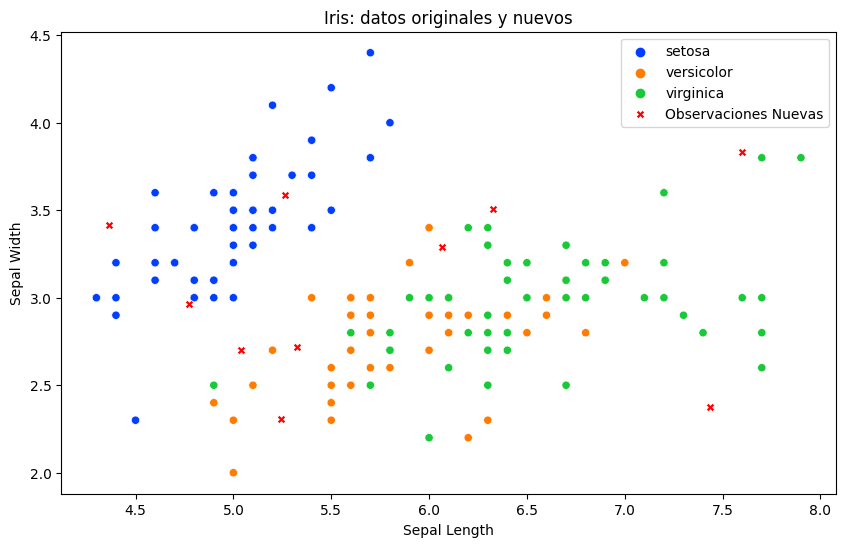

In [10]:
# Escoger dos variables
x_var, y_var = 'sepal_length', 'sepal_width'

# Scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=iris, x=x_var, y=y_var, hue='species', palette='bright')

# Nuevas observaciones
sns.scatterplot(x=obs_aleatorias_df[x_var], y=obs_aleatorias_df[y_var], color='red', marker='X', label='Observaciones Nuevas')

# Muestra plot
plt.title('Iris: datos originales y nuevos')
plt.xlabel(x_var.replace('_', ' ').title())
plt.ylabel(y_var.replace('_', ' ').title())
plt.legend()
plt.show()

In [11]:
# Aquí puedes copiar y pegar el código anterior para hacer gráficas con pares diferentes de variables
# (Reto de visualización: puedes mostrar las 6 combinaciones, con todo y los puntos rojos nuevos?)

# Recuerda que tienes que cambiar la primera línea por los nombres de variables, que pueden ser:
# sepal_length sepal_width petal_length petal_width







## Construyamos un KNN sencillo

In [12]:
from sklearn.neighbors import KNeighborsClassifier

# k número de vecinos
k = 3

knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X, y)
y_pred = knn.predict(obs_aleatorias_df)
y_pred

array(['virginica', 'versicolor', 'virginica', 'versicolor', 'versicolor',
       'versicolor', 'setosa', 'virginica', 'versicolor', 'versicolor'],
      dtype=object)

In [13]:
# Agreguemos las predicciones al dataframe y cobminemos en uno nuevo para hacer la gráfica fácil
iris_nuevos = iris.copy()
iris_nuevos['tipo'] = "Original"

obs_aleatorias_df['species'] = y_pred
obs_aleatorias_df['tipo'] = 'Nueva'

iris_nuevos = pd.concat([iris_nuevos, obs_aleatorias_df])

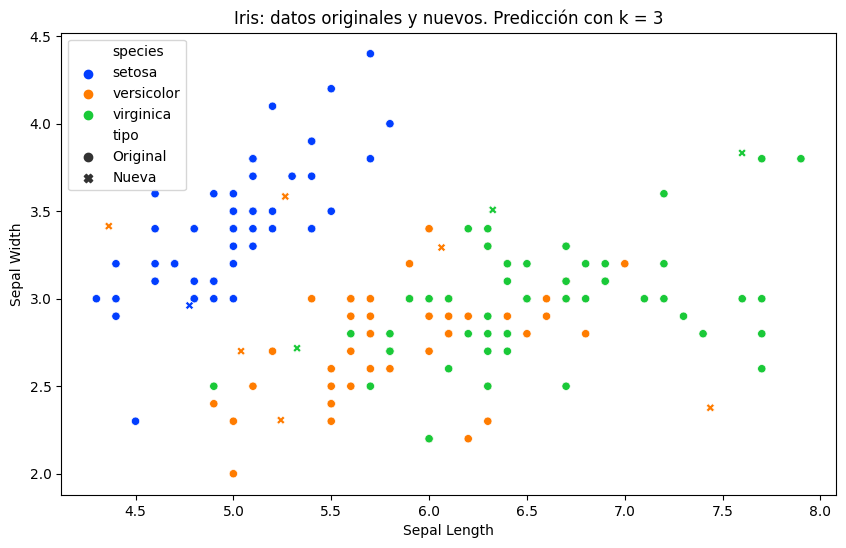

In [14]:
# Escoger dos variables
x_var, y_var = 'sepal_length', 'sepal_width'

# Scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=iris_nuevos, x=x_var, y=y_var, hue='species', palette='bright', style='tipo')

# Muestra plot
plt.title('Iris: datos originales y nuevos. Predicción con k = ' + str(k))
plt.xlabel(x_var.replace('_', ' ').title())
plt.ylabel(y_var.replace('_', ' ').title())
plt.legend()
plt.show()



¡Importante! En este proceso no separamos los datos en train y test. Aprenderemos a hacer esto en la siguiente clase, es un paso vital en el pipeline de un modelo, pero por el momento solo queremos visualizar.